In [18]:
# Imports
import os
import random
import numpy as np
import pandas as pd
from pathlib import Path

# TensorFlow specific
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_cv

# Scikit-learn and utils
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
# Only importing metrics based on Accuracy, Precision, and F1
from sklearn.metrics import precision_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm


In [19]:
# Mount Google Drive
from google.colab import drive
try:
    drive.mount('/content/drive', force_remount=False)
except Exception as e:
    print(f"Drive not mounted: {e}. Ensure running in Colab.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
# --- Configuration ---
SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 20
INITIAL_LR = 1e-4
WEIGHT_DECAY = 1e-4
n_classes =7

In [21]:
# Paths to metadata set and image folders
data_dir = "/content/drive/MyDrive/data"
metadata_path = os.path.join(data_dir, "HAM10000_metadata.csv")
image_dirs = [
    os.path.join(data_dir, "HAM10000_images_part_1"),
    os.path.join(data_dir, "HAM10000_images_part_2")
]


In [22]:
# Saving the best model
OUTPUT_DIR = "./efficientnet_accuracy_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)
BEST_MODEL_PATH = os.path.join(OUTPUT_DIR, "best_efficientnet_accuracy.keras")


In [23]:
#  Reproducibility Function
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(SEED)
print(f"TensorFlow Version: {tf.__version__}")


TensorFlow Version: 2.20.0


In [24]:
# Data Loading, Encoding, and Splitting

print("\n--- Starting Data Preparation ---")
df = pd.read_csv(metadata_path)

# Map image IDs to their full local paths
path_map = {}
def add_files(file_list, folder_path):
    for fname in file_list:
        if fname.lower().endswith((".jpg", ".png")):
            path_map[fname] = os.path.join(folder_path, fname)

add_files(os.listdir(image_dirs[0]), image_dirs[0])
add_files(os.listdir(image_dirs[1]), image_dirs[1])

df["path"] = df["image_id"].apply(lambda x: path_map.get(f"{x}.jpg"))
df = df.dropna(subset=["path"]).reset_index(drop=True)
print("Images found:", len(df))




--- Starting Data Preparation ---
Images found: 10015


In [25]:
# Label Encoding
le = LabelEncoder()
encoded_labels = le.fit_transform(df["dx"])
n_classes = len(le.classes_)
image_paths = df["path"].values

print(f"Number of classes: {n_classes}. Class names: {le.classes_}")


Number of classes: 7. Class names: ['akiec' 'bcc' 'bkl' 'df' 'mel' 'nv' 'vasc']


In [26]:
#  Compute Class Weights (needed for balanced training loss)
unique_classes = np.unique(encoded_labels)
class_weights_np = compute_class_weight(
    class_weight="balanced",
    classes=unique_classes,
    y=encoded_labels
)
class_weights_dict = {i: weight for i, weight in enumerate(class_weights_np)}
print("Keras Class Weights (dict):", class_weights_dict)


Keras Class Weights (dict): {0: np.float64(4.375273044997815), 1: np.float64(2.78349082823791), 2: np.float64(1.301832835044846), 3: np.float64(12.440993788819876), 4: np.float64(1.2854575792581184), 5: np.float64(0.21338020666879728), 6: np.float64(10.075452716297788)}


In [27]:
# Train/Val/Test Split (stratified)
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths, encoded_labels, test_size=0.2, stratify=encoded_labels, random_state=SEED
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, stratify=temp_labels, random_state=SEED
)
print(f"Train samples: {len(train_paths)}, Val samples: {len(val_paths)}, Test samples: {len(test_paths)}")


Train samples: 8012, Val samples: 1001, Test samples: 1002


In [28]:
# TensorFlow Data Pipeline (tf.data)

def load_and_preprocess_image(path, label, img_size=IMG_SIZE):
    """Reads image, decodes, resizes, and ensures correct label type."""
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.convert_image_dtype(img, dtype=tf.float32) # [0, 1] normalization
    img = tf.image.resize(img, [img_size, img_size])

    # Ensure label is an integer scalar
    label = tf.cast(label, tf.int32)
    return img, label

def augment_fn(img, label):
    """Data augmentation for training set."""
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.2)
    img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
    return img, label

def create_tf_dataset(paths, labels, is_training=False):
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    dataset = dataset.map(lambda x, y: load_and_preprocess_image(x, y, IMG_SIZE),
                          num_parallel_calls=tf.data.AUTOTUNE)

    if is_training:
        dataset = dataset.map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE)
        dataset = dataset.shuffle(buffer_size=1024)

    dataset = dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return dataset

# Create Keras Datasets
train_ds_tf = create_tf_dataset(train_paths, train_labels, is_training=True)
val_ds_tf = create_tf_dataset(val_paths, val_labels, is_training=False)
test_ds_tf = create_tf_dataset(test_paths, test_labels, is_training=False)
print("TensorFlow datasets created.")




TensorFlow datasets created.


In [29]:
# Create Model (EfficientNetV2)

print("\n--- Creating EfficientNetV2 Model ---")

def create_efficientnet_model(num_classes=n_classes):
    """Creates a stable EfficientNetV2B0 model using Keras Applications."""

    base_model = keras.applications.EfficientNetV2B0(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        pooling='avg'
    )
    base_model.trainable = True

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs)
    x = layers.Dense(num_classes, activation='softmax', name="predictions")(x)

    model = keras.Model(inputs=inputs, outputs=x, name="EfficientNetV2_Classifier")
    return model

# CRITICAL ASSIGNMENT
keras_model = create_efficientnet_model(num_classes=n_classes)
keras_model.summary(expand_nested=True)



--- Creating EfficientNetV2 Model ---


Model: "EfficientNetV2_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 1280)           │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ input_layer_2 (InputLayer) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ rescaling_1 (Rescaling)    │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ normalization_1            │ (None, 224, 224, 3)    │             0 │
│ (Normalization)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ stem_conv (Conv2D)         │ (None, 112, 112, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ stem_bn                    │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ stem_activation            │ (None, 112, 112, 32)   │             0 │
│ (Activation)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block1a_project_conv       │ (None, 112, 112, 16)   │         4,608 │
│ (Conv2D)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block1a_project_bn         │ (None, 112, 112, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block1a_project_activation │ (None, 112, 112, 16)   │             0 │
│ (Activation)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block2a_expand_conv        │ (None, 56, 56, 64)     │         9,216 │
│ (Conv2D)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block2a_expand_bn          │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block2a_expand_activation  │ (None, 56, 56, 64)     │             0 │
│ (Activation)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block2a_project_conv       │ (None, 56, 56, 32)     │         2,048 │
│ (Conv2D)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block2a_project_bn         │ (None, 56, 56, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block2b_expand_conv        │ (None, 56, 56, 128)    │        36,864 │
│ (Conv2D)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block2b_expand_bn          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 5,928,279 (22.61 MB)

 Trainable params: 5,867,671 (22.38 MB)

 Non-trainable params: 60,608 (236.75 KB)

In [30]:
# Compile and Train (Accuracy Monitoring)

print("\n--- Compiling and Training Model ---")
# Optimizer: AdamW
optimizer_keras = keras.optimizers.AdamW(learning_rate=INITIAL_LR, weight_decay=WEIGHT_DECAY)

# Loss: SparseCategoricalCrossentropy
criterion_keras = keras.losses.SparseCategoricalCrossentropy()

# Metrics: Only 'accuracy'
metrics = [
    'accuracy'
]

keras_model.compile(
    optimizer=optimizer_keras,
    loss=criterion_keras,
    metrics=metrics
)


--- Compiling and Training Model ---


In [31]:
# Callbacks

# Learning Rate Scheduler: CosineAnnealingLR equivalent
def cosine_decay_scheduler(epoch, initial_lr, t_max):
    return initial_lr * (0.5 + 0.5 * np.cos(np.pi * epoch / t_max))

lr_schedule = keras.callbacks.LearningRateScheduler(
    lambda epoch: cosine_decay_scheduler(epoch, INITIAL_LR, EPOCHS),
    verbose=1
)

# Model Checkpoint: Saves the best model based on validation ACCURACY
checkpoint_callback = keras.callbacks.ModelCheckpoint(
    filepath=BEST_MODEL_PATH,
    monitor='val_accuracy', # Monitoring validation ACCURACY
    mode='max',
    save_best_only=True,
    verbose=1
)


In [32]:
# Run Training
print("Starting training...")
history = keras_model.fit(
    train_ds_tf,
    validation_data=val_ds_tf,
    epochs=EPOCHS,
    class_weight=class_weights_dict, # Apply balanced class weights
    callbacks=[lr_schedule, checkpoint_callback]
)

print(f"\nTraining complete. Best model saved to: {BEST_MODEL_PATH}")


Starting training...

Epoch 1: LearningRateScheduler setting learning rate to 0.0001.
Epoch 1/20
501/501 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3389 - loss: 1.6229
Epoch 1: val_accuracy improved from -inf to 0.61339, saving model to ./efficientnet_accuracy_output/best_efficientnet_accuracy.keras
501/501 ━━━━━━━━━━━━━━━━━━━━ 1450s 2s/step - accuracy: 0.3392 - loss: 1.6225 - val_accuracy: 0.6134 - val_loss: 1.1506 - learning_rate: 1.0000e-04

Epoch 2: LearningRateScheduler setting learning rate to 9.938441702975689e-05.
Epoch 2/20
501/501 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.5681 - loss: 1.0757
Epoch 2: val_accuracy did not improve from 0.61339
501/501 ━━━━━━━━━━━━━━━━━━━━ 99s 179ms/step - accuracy: 0.5681 - loss: 1.0756 - val_accuracy: 0.1868 - val_loss: 2.3643 - learning_rate: 9.9384e-05

Epoch 3: LearningRateScheduler setting learning rate to 9.755282581475769e-05.
Epoch 3/20
501/501 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.6255 - loss: 0.8863
Epoch 3: val_a

In [67]:
# Note: test_results will only have loss and accuracy now (test_results[0] and test_results[1])
print(f"Test Loss: {test_results[0]:.4f}")
print(f"Test Accuracy: {test_results[1]:.4f}")

Test Loss: 0.6533
Test Accuracy: 0.7934


In [65]:
# Downloaded the best model
from google.colab import files
files.download('./efficientnet_accuracy_output/best_efficientnet_accuracy.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [66]:
# 6. Evaluation and Visualization

print("\n--- Evaluating Best Model ---")
# Load the best saved model
try:
    best_keras_model = keras.models.load_model(BEST_MODEL_PATH)
except Exception:
    print("Could not load best model. Using the last epoch's model for evaluation.")
    best_keras_model = keras_model

# Evaluate on Test Set
test_results = best_keras_model.evaluate(test_ds_tf)


--- Evaluating Best Model ---
63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 195ms/step - accuracy: 0.7901 - loss: 0.6739


In [36]:
# --- Calculate Detailed Metrics (Precision and F1 Score) ---
all_test_preds = []
all_test_targets = []

for images, labels in tqdm(test_ds_tf, desc="Generating Test Predictions"):
    preds = best_keras_model.predict_on_batch(images)
    all_test_preds.extend(np.argmax(preds, axis=1))
    all_test_targets.extend(labels.numpy())

y_true = np.array(all_test_targets)
y_pred = np.array(all_test_preds)

# Compute Metrics (using sklearn for completeness)
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)

# ADDED RECALL CALCULATION
recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)

f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print(f"\nWeighted Precision (Test): {precision:.4f}")
print(f"Weighted Recall (Test): {recall:.4f}") # Display the new metric
print(f"Weighted F1 Score (Test): {f1:.4f}")

Generating Test Predictions: 100%|██████████| 63/63 [00:40<00:00,  1.54it/s]


Weighted Precision (Test): 0.8242
Weighted Recall (Test): 0.7934
Weighted F1 Score (Test): 0.8034


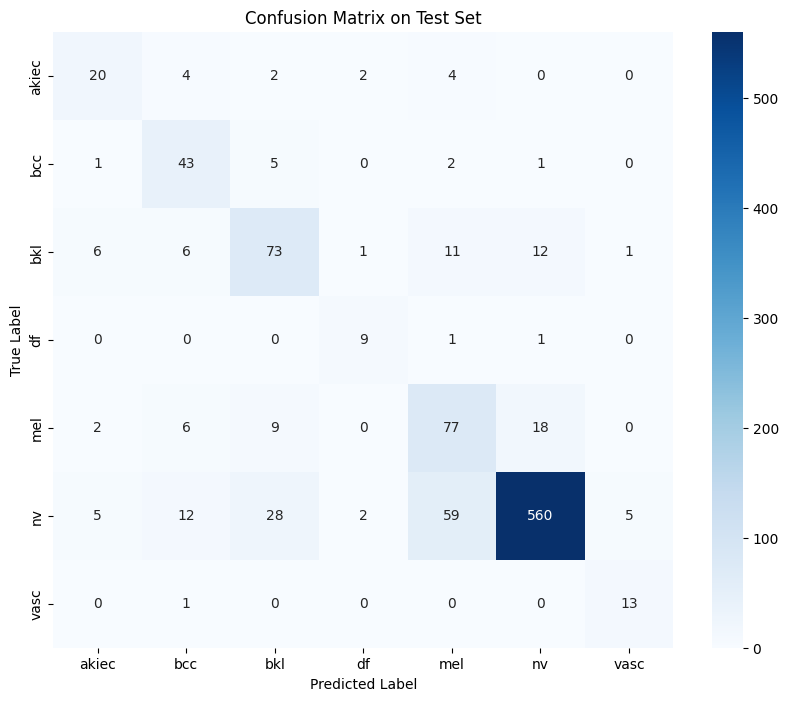

In [37]:
# Confusion Matrix Visualization
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix on Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

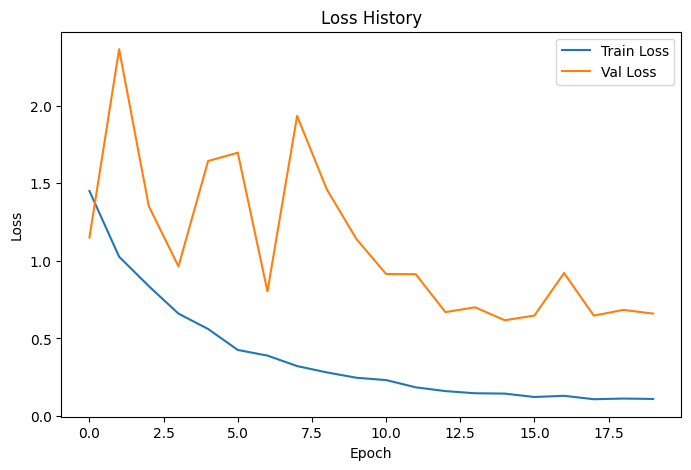

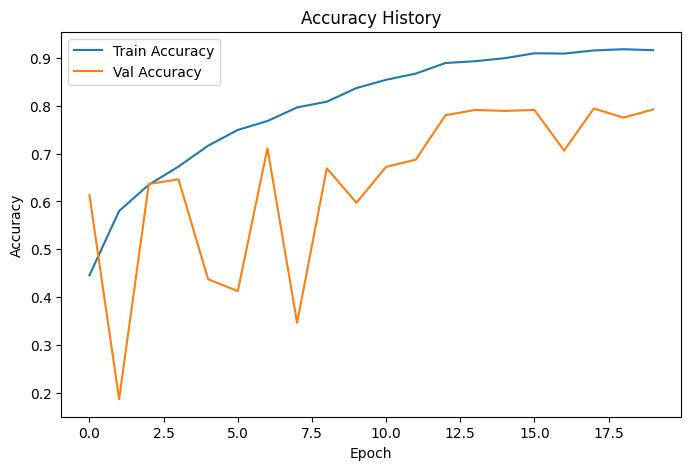

In [38]:
# Plotting Training History
def plot_history(history):
    plt.figure(figsize=(8, 5))

    # Loss plot
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Loss History')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    # Accuracy plot
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Accuracy History')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()


plot_history(history)

Class Names: ['akiec' 'bcc' 'bkl' 'df' 'mel' 'nv' 'vasc']
Model loaded: EfficientNetV2_Classifier
Image size expected: 224

Attempting prediction for file: /content/drive/MyDrive/data/HAM10000_images_part_1/ISIC_0026861.jpg
**ACTUAL LABEL: bkl**
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
--- Prediction ---
Predicted Lesion: **bkl**
Confidence: 41.56*%


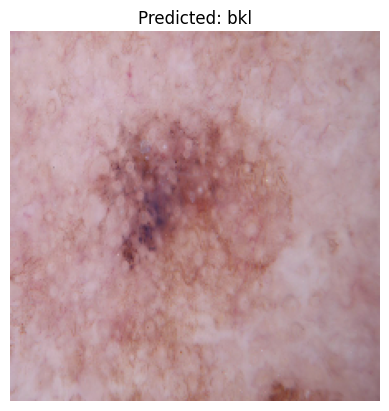

In [57]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Assuming IMG_SIZE, best_keras_model, test_paths, test_labels, and le (LabelEncoder) are defined.

# -------------------------
# Define Class Names for readable output
# -------------------------
# Get the class names from your LabelEncoder (e.g., ['mel', 'nv', 'bcc', ...])
class_names = le.classes_
print("Class Names:", class_names)
print("Model loaded:", best_keras_model.name)
print("Image size expected:", IMG_SIZE)


# -------------------------
# Step 1: Load and Preprocess Function
# -------------------------
def load_and_preprocess_image_tf(path, img_size=IMG_SIZE):
    """
    Loads, decodes, resizes, normalizes, and adds batch dimension
    to a single image file path using TensorFlow operations.
    """
    try:
        # 1. Read file
        image = tf.io.read_file(path)
        # 2. Decode image (assuming JPEG)
        image = tf.image.decode_jpeg(image, channels=3)
    except tf.errors.NotFoundError:
        print(f"Error: File not found at path: {path}")
        return None

    # 3. Resize
    image = tf.image.resize(image, [img_size, img_size])
    # 4. Normalize (to [0, 1])
    image = tf.cast(image, tf.float32) / 255.0
    # 5. Add batch dimension: (H, W, C) -> (1, H, W, C)
    image = tf.expand_dims(image, axis=0)
    return image

# -------------------------
# Step 2: Prediction Function
# -------------------------
def predict_image(model, img_path, class_names):
    """
    Loads an image, makes a prediction, and prints the result.
    """
    # Load and preprocess the image tensor
    img = load_and_preprocess_image_tf(img_path)

    if img is None:
        return # Exit if file reading failed

    # Run prediction
    # model.predict returns an array of shape (1, n_classes)
    preds = model.predict(img)

    # Get the index with the highest probability
    pred_index = np.argmax(preds[0])

    # Map index to class name
    pred_class = class_names[pred_index]

    # Print result and confidence
    confidence = preds[0][pred_index]

    print("--- Prediction ---")
    print(f"Predicted Lesion: **{pred_class}**")
    print(f"Confidence: {confidence*100:.2f}*%")

    # Optional: Display the image
    plt.imshow(tf.squeeze(img, axis=0).numpy())
    plt.title(f"Predicted: {pred_class}")
    plt.axis('off')
    plt.show()

# -------------------------
# Example Usage (Adapt the path!)
# -------------------------
# Use a path from your previously split test set or provide a new one
try:
    # 1. Select the index for testing
    test_index_in_list = 920

    # 2. Retrieve the path and the corresponding encoded label from the test set lists
    test_image_path = test_paths[test_index_in_list]
    true_encoded_label = test_labels[test_index_in_list]

    # 3. Decode the actual label using the LabelEncoder
    actual_label = le.inverse_transform([true_encoded_label])[0]

    print(f"\nAttempting prediction for file: {test_image_path}")
    print(f"**ACTUAL LABEL: {actual_label}**") # Display the actual label

    # Run the prediction
    predict_image(best_keras_model, test_image_path, class_names)

except NameError:
    print("\nError: Make sure 'best_keras_model', 'test_paths', 'test_labels', and 'le' are defined by running Sections 1-6 first.")
except IndexError:
    # This catches an error if the selected index is out of bounds
    print(f"\nError: Index {test_index_in_list} is out of bounds for the test set (Size: {len(test_paths)}). Choose a smaller index.")
except Exception as e:
    print(f"\nAn error occurred during prediction: {e}")